In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

In [2]:
def reward(action=None, glucose_level=None, glucose_target=None, metabolism=None, intake=None):
    if (action == 'EAT'):
        return (2*glucose_level-2*glucose_target-metabolism+intake)*(metabolism-intake)
    else:
        return (2*glucose_level-2*glucose_target-metabolism)*(metabolism)

In [3]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
metabolism = 5
intake = 10
action = 'EAT'

rewards = reward(action, glucose_range, glucose_target, metabolism, intake)

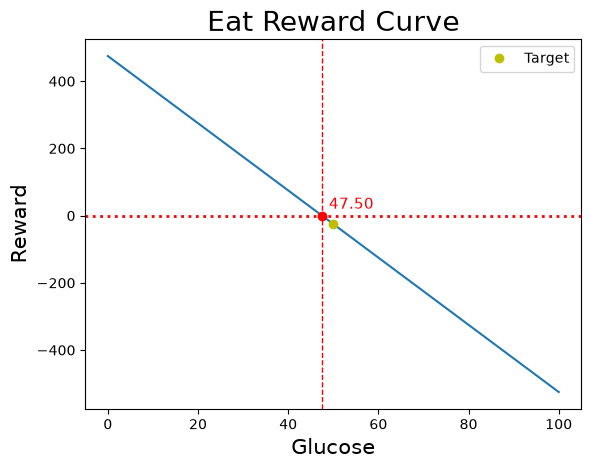

In [4]:
# 2. Exact root-finding using the actual function (not the sampled array)
#    Pick bounds where you know the function changes sign
x_zero = brentq(lambda glucose_level: reward(action, glucose_level, glucose_target, metabolism, intake), 0, 100)

# 3. Plot
plt.plot(glucose_range, rewards)
plt.axhline(y=0, color='r', linestyle=':', linewidth=2)

plt.axvline(x=x_zero, color='r', linestyle='--', linewidth=1)
plt.plot(x_zero, 0, 'ro')
plt.annotate(f'{x_zero:.2f}', (x_zero, 0), textcoords="offset points",
             xytext=(5, 5), fontsize=11, color='red')

plt.plot(glucose_target, reward(action, glucose_target, glucose_target, metabolism, intake), 'yo', label = 'Target')

plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve", fontsize=20)
plt.legend()
plt.savefig("../plots/eat-reward.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
action = 'EAT'

#metabolisms = [1, 5, 10, 15]
metabolism = 5

#intake = 10
intakes = [1, 5, 10, 15]

rewards = {}
for i in intakes:
    rewards[i] = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=i)

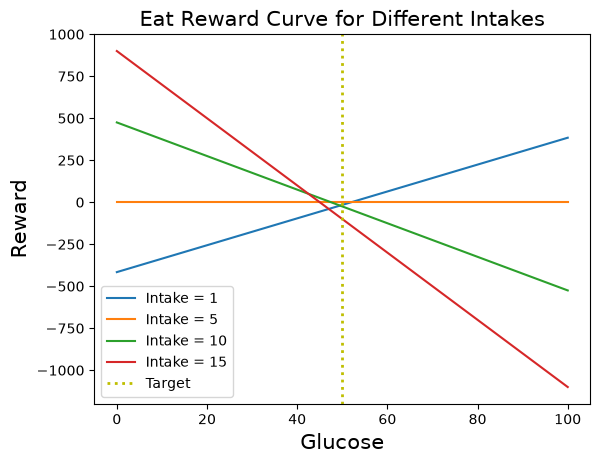

In [6]:
for i in intakes:
    plt.plot(glucose_range, rewards[i], label=f'Intake = {i}')
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve for Different Intakes", fontsize=15)
#plt.axhline(y=0, color='r', linestyle=':', linewidth=2)
plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')
plt.legend()
plt.savefig("../plots/eat-reward-diff-i.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
def drive(glucose_level=None, glucose_target=None, n=None, m=None):
    return ((abs(glucose_level - glucose_target)) ** n) ** (1/m)

In [8]:
glucose_range = np.linspace(0, 100, 1000)
glucose_target = 50
n=4
m=3

drives = drive(glucose_range, glucose_target, n, m)

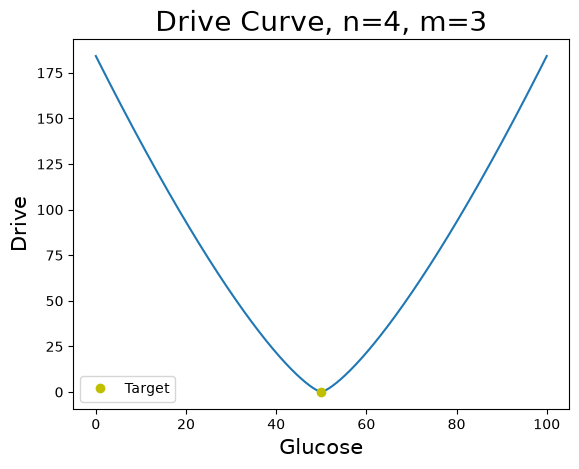

In [9]:
plt.plot(glucose_range, drives)
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Drive", fontsize=15)
plt.title(f"Drive Curve, n={n}, m={m}", fontsize=20)
plt.plot(glucose_target, drive(glucose_target, glucose_target, n, m), 'yo', label = 'Target')
plt.legend()
plt.savefig(f"../plots/drive-curve-n{n}-m{m}.png", dpi=300, bbox_inches='tight')

In [2]:
def reward(action=None, glucose_level=None, glucose_target=None, metabolism=None, intake=None, n=None, m=None):
    cur_drive = drive(glucose_level, glucose_target, n, m)
    if (action == 'EAT'):
        next_glucose = glucose_level + intake - metabolism
    else:
        next_glucose = glucose_level - metabolism
    next_drive = drive(next_glucose, glucose_target, n, m)
    return cur_drive - next_drive

In [46]:
glucose_range = np.linspace(0, 100, 100)
glucose_target = 50
action = 'EAT'

metabolism = 10
#metabolisms = [1, 5, 10, 15]

intake = 15
#intakes = [1, 5, 10, 15]

n=1
m=2

eat_rewards = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=intake, n=n, m=m)
print(eat_rewards)

[ 0.36286388  0.36679032  0.37084717  0.37504182  0.37938227  0.38387717
  0.38853591  0.39336871  0.3983867   0.40360204  0.40902802  0.41467925
  0.42057177  0.4267233   0.43315341  0.43988384  0.44693876  0.45434517
  0.46213334  0.47033732  0.47899558  0.48815179  0.49785575  0.50816452
  0.51914393  0.5308703   0.54343275  0.55693615  0.57150483  0.58728755
  0.60446412  0.62325427  0.64392996  0.66683265  0.69239827  0.72119416
  0.75397566  0.7917764   0.83605901  0.88898263  0.95391566  1.03652724
  1.14749272  1.31109173  1.61166661  1.4578073   0.67002779  0.0159713
 -0.63585998 -1.40946054 -1.63561535 -1.32156457 -1.15411506 -1.04127915
 -0.95756474 -0.89190884 -0.83847803 -0.79382205 -0.75573639 -0.7227313
 -0.69375595 -0.66804358 -0.64501901 -0.62424075 -0.60536328 -0.58811163
 -0.57226378 -0.55763816 -0.54408463 -0.53147776 -0.51971182 -0.50869698
 -0.49835631 -0.48862354 -0.47944118 -0.4707591  -0.46253336 -0.45472525
 -0.44730049 -0.44022866 -0.43348261 -0.42703801 -0.4

In [47]:
action = 'NO EAT'
no_eat_rewards = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=intake, n=n, m=m)
print(no_eat_rewards)

[-0.67489888 -0.68120974 -0.68770154 -0.69438313 -0.70126397 -0.7083542
 -0.7156647  -0.72320714 -0.73099412 -0.73903919 -0.74735699 -0.75596334
 -0.76487542 -0.77411184 -0.78369288 -0.79364061 -0.80397918 -0.81473502
 -0.82593716 -0.83761753 -0.84981142 -0.86255785 -0.8759002  -0.88988679
 -0.90457167 -0.92001549 -0.93628665 -0.95346259 -0.97163141 -0.99089385
 -1.01136579 -1.03318129 -1.05649655 -1.08149489 -1.10839322 -1.1374506
 -1.16897962 -1.20336185 -1.24106935 -1.28269516 -1.32899779 -1.38096836
 -1.4399357  -1.50773923 -1.58703058 -1.68184319 -1.79878889 -1.94999904
 -2.16248332 -2.53048051 -2.37071854 -1.68196142 -1.14489413 -0.66231332
 -0.20348967  0.2488375   0.70915555  1.19541152  1.7409868   2.46209286
  2.47819579  2.1369656   1.93277049  1.78581955  1.67150401  1.57848428
  1.50049401  1.43367678  1.37548166  1.32413105  1.27833619  1.23713318
  1.19978261  1.16570525  1.13443928  1.10561088  1.07891343  1.05409255
  1.03093502  1.0092605   0.98891522  0.96976708  0.9

In [48]:
print(eat_rewards > no_eat_rewards)
print(np.argmin(eat_rewards > no_eat_rewards))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
52


In [13]:
rewards = {}
for i in intakes:
    rewards[i] = reward(action=action, glucose_level=glucose_range, glucose_target=glucose_target, metabolism=metabolism, intake=i, n=n, m=m)

ValueError: x and y must have same first dimension, but have shapes (1000,) and (1,)

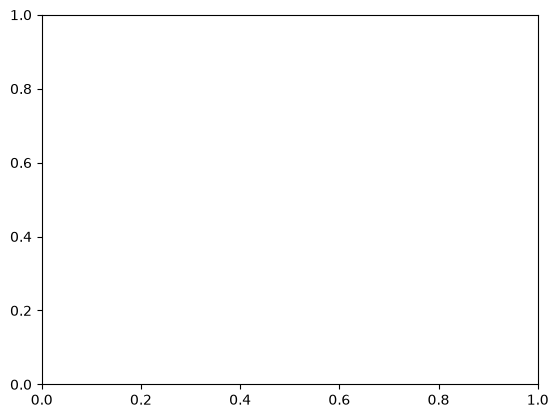

In [15]:
# 2. Exact root-finding using the actual function (not the sampled array)
#    Pick bounds where you know the function changes sign
#x_zero = brentq(lambda glucose_level: reward(action, glucose_level, glucose_target, metabolism, intake), 0, 100)

# 3. Plot
plt.plot(glucose_range, rewards)
plt.axhline(y=0, color='r', linestyle=':', linewidth=2)

#plt.axvline(x=x_zero, color='r', linestyle='--', linewidth=1)
#plt.plot(x_zero, 0, 'ro')
#plt.annotate(f'{x_zero:.2f}', (x_zero, 0), textcoords="offset points",
#             xytext=(5, 5), fontsize=11, color='red')

plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')

plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve", fontsize=20)
plt.legend()
plt.savefig("../plots/n4-m3-g70.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
for i in intakes:
    plt.plot(glucose_range, rewards[i], label=f'Intake  = {i}')
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Eat Reward Curve for Different Intakes", fontsize=15)
#plt.axhline(y=0, color='r', linestyle=':', linewidth=2)
plt.axvline(x=glucose_target, color='y', linestyle=':', linewidth=2, label='Target')
plt.legend()
plt.savefig("../plots/n2-m3-diff-intakes.png", dpi=300, bbox_inches='tight')
plt.show()